# Kyrgyzstan Education Statistics: A Statistical Analysis Report

**Course:** Statistics Final Project 
**Dataset:** Official National Statistics of the Kyrgyz Republic — Education Sector  
**Files Used:**
- `literacy.csv` — Literacy of population (census data: 1989, 1999, 2009, 2022)
- `students_cis.csv` — International students from CIS countries (2010–2024)
- `students_non_cis.csv` — International students from non-CIS countries (2010–2024)
- `education_budget.csv` — State budget expenditures on education (2001–2025)

---

## 1. Dataset Description

This report analyzes four official statistical datasets published by the National Statistics Committee of the Kyrgyz Republic, covering the period from 1989 to 2025. The datasets capture:

1. **Literacy rates and education attainment** across four census years (1989, 1999, 2009, 2022)
2. **Foreign student enrollment** from CIS and non-CIS countries in Kyrgyz higher education institutions (2010–2024)
3. **State budget allocations** to the education sector across major sub-sectors (2001–2025 projected)

The datasets are trilingual (Kyrgyz, Russian, English) and reflect post-Soviet education system transformations.

## 2. Research Questions

1. How has population literacy evolved across the four census years (1989–2022)?
2. What is the trend in international student enrollment, and do CIS vs. non-CIS students show different patterns?
3. Is there a significant correlation between total education budget and international student enrollment?
4. How is the education budget distributed across sub-sectors (pre-school, general, higher, vocational)?
5. Is the growth in non-CIS students significantly different from CIS students (hypothesis test)?

## 3. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# Load CSVs
literacy_raw = pd.read_csv('../data/literacy.csv', encoding='utf-8-sig')
cis_raw = pd.read_csv('../data/students_cis.csv', encoding='utf-8-sig')
non_cis_raw = pd.read_csv('../data/students_non_cis.csv', encoding='utf-8-sig')
budget_raw = pd.read_csv('../data/education_budget.csv', encoding='utf-8-sig')

print('Shapes:')
print(f'  Literacy:      {literacy_raw.shape}')
print(f'  CIS students:  {cis_raw.shape}')
print(f'  Non-CIS:       {non_cis_raw.shape}')
print(f'  Budget:        {budget_raw.shape}')

FileNotFoundError: [Errno 2] No such file or directory: './data/literacy.csv'

## 4. Data Cleaning & Preparation

In [ ]:
# ── Literacy ──────────────────────────────────────────────────────────────────
literacy = literacy_raw[['Items', '1989', '1999', '2009', '2022']].copy()
literacy.columns = ['Category', '1989', '1999', '2009', '2022']
literacy['Category'] = literacy['Category'].str.strip()

# Keep only meaningful rows (drop notes/subtitles)
literacy = literacy[literacy['Category'].notna() & (literacy['Category'] != '')].reset_index(drop=True)

# Convert to numeric
for col in ['1989', '1999', '2009', '2022']:
    literacy[col] = pd.to_numeric(literacy[col], errors='coerce')

literacy_clean = literacy[literacy['1989'].notna() | literacy['2022'].notna()].copy()
print('Literacy categories:')
literacy_clean

Literacy categories:


,Category,1989,1999,2009,2022
0,Total population with education at age 15 yea...,2661901.0,3090680.0,3738226.0,4645716.0
1,Higher professional education,251246.0,324414.0,463346.0,1134147.0
2,Incomplete higher education,43245.0,47706.0,133196.0,226059.0
3,Secondary professional education,418716.0,333181.0,264208.0,819150.0
4,Initial professional education,NaN,NaN,197476.0,184963.0
5,Secondary general education1,1040494.0,1545626.0,1968846.0,1607987.0
6,Incomplete secondary education,489786.0,566351.0,443594.0,442062.0
7,Elementary education,240922.0,193767.0,203717.0,182196.0
8,Formal education,177492.0,79635.0,63843.0,49152.0
10,Illiterates,80417.0,40129.0,28358.0,86330.0


In [28]:
# ── International students ────────────────────────────────────────────────────
year_cols = [str(y) for y in range(2010, 2025)]

def extract_by_country(df, group_label):
    """Return a DataFrame with one row per country and one column per year."""
    en_col = df.columns[2]  # English label column
    skip = {'total', 'ncluding:', 'including:', '', 'nan'}
    rows = []
    for _, row in df.iterrows():
        name = str(row[en_col]).strip()
        if name.lower() in skip or 'Including' in name:
            continue
        vals = pd.to_numeric(pd.Series([row[y] for y in year_cols]), errors='coerce').values
        rows.append({'Country': name, 'Group': group_label, **dict(zip(year_cols, vals))})
    return pd.DataFrame(rows)

def extract_totals(df):
    """Return the 'Total' row as a Series indexed by year (kept for aggregate use)."""
    en_col = df.columns[2]
    total_mask = df[en_col].astype(str).str.strip().str.lower().isin(['total'])
    row = df[total_mask].iloc[0]
    return pd.to_numeric(row[year_cols], errors='coerce')

# Per-country DataFrames
cis_countries = extract_by_country(cis_raw, 'CIS')
non_cis_countries = extract_by_country(non_cis_raw, 'Non-CIS')
countries_df = pd.concat([cis_countries, non_cis_countries], ignore_index=True)

print('Students by country:')
display(countries_df)

# Aggregate totals (CIS / Non-CIS / Total per year) — used in later analysis
cis_total = extract_totals(cis_raw)
non_cis_total = extract_totals(non_cis_raw)

students_df = pd.DataFrame({
    'Year': [int(y) for y in year_cols],
    'CIS': cis_total.values,
    'Non_CIS': non_cis_total.values
})
students_df['Total'] = students_df['CIS'] + students_df['Non_CIS']
students_df['CIS_pct'] = students_df['CIS'] / students_df['Total'] * 100
students_df['NonCIS_pct'] = students_df['Non_CIS'] / students_df['Total'] * 100

print('\nInternational students (Total per year):')
students_df

International students (Total per year):


,Year,CIS,Non_CIS,Total,CIS_pct,NonCIS_pct
0,2010,9814.0,3366.0,13180.0,74.461305,25.538695
1,2011,7068.0,3099.0,10167.0,69.519032,30.480968
2,2012,7977.0,3286.0,11263.0,70.824825,29.175175
3,2013,8195.0,3467.0,11662.0,70.270966,29.729034
4,2014,8466.0,4257.0,12723.0,66.540910,33.459090
5,2015,8908.0,5627.0,14535.0,61.286550,38.713450
6,2016,8194.0,6520.0,14714.0,55.688460,44.311540
7,2017,7653.0,8881.0,16534.0,46.286440,53.713560
8,2018,8764.0,10862.0,19626.0,44.655049,55.344951
9,2019,21049.0,15547.0,36596.0,57.517215,42.482785


In [5]:
# ── Education budget ──────────────────────────────────────────────────────────
budget = budget_raw.copy()
en_col = budget.columns[2]
budget[en_col] = budget[en_col].astype(str).str.strip()

b_years = [str(y) for y in range(2001, 2025)]
for col in b_years:
    if col in budget.columns:
        budget[col] = pd.to_numeric(budget[col], errors='coerce')

budget_labels = budget[en_col].tolist()
print('Budget categories:')
for i, lbl in enumerate(budget_labels):
    print(f'  [{i}] {lbl}')

Budget categories:
  [0] State budget expenditures on education, total
  [1] of which:
  [2] on pre-school education
  [3] on secondary education2
  [4] on higher education
  [5] 1 Including expenses for the acquisition of non-financial assets.
  [6] 2 Including general education programs of primary and secondary vocational education, as well as continued secondary technical education.
  [7] * Operational data.


In [6]:
# Extract key budget rows
def get_budget_row(keyword):
    mask = budget[en_col].str.lower().str.contains(keyword, na=False)
    if mask.any():
        return budget[mask].iloc[0][b_years].astype(float)
    return None

budget_total_row   = get_budget_row('total')
budget_preschool   = get_budget_row('pre-school')
budget_general     = get_budget_row('general secondary')
budget_higher      = get_budget_row('higher')
budget_vocational  = get_budget_row('vocational')

# Build clean budget time series
budget_ts = pd.DataFrame({
    'Year': [int(y) for y in b_years],
    'Total_mln_som': budget_total_row.values if budget_total_row is not None else np.nan,
    'Preschool': budget_preschool.values if budget_preschool is not None else np.nan,
    'Higher': budget_higher.values if budget_higher is not None else np.nan,
})
if budget_general is not None:
    budget_ts['General_Secondary'] = budget_general.values
if budget_vocational is not None:
    budget_ts['Vocational'] = budget_vocational.values

print('Budget time series (first 5 rows):')
print(budget_ts.head())

Budget time series (first 5 rows):
   Year  Total_mln_som  Preschool  Higher  Vocational
0  2001         2847.6      190.0   490.3         NaN
1  2002         3350.4      219.5   657.3         NaN
2  2003         3753.6      232.1   747.3         NaN
3  2004         4361.3      257.2   864.3         NaN
4  2005         4917.7      304.1   943.3         NaN


## 5. Descriptive Statistics

In [7]:
print('=== International Students: Descriptive Statistics ===')
print(students_df[['CIS', 'Non_CIS', 'Total']].describe().round(1))

=== International Students: Descriptive Statistics ===
           CIS  Non_CIS    Total
count     15.0     15.0     15.0
mean   19903.9  12240.9  32144.9
std    16900.1   9141.6  25173.4
min     7068.0   3099.0  10167.0
25%     8194.5   3862.0  12951.5
50%     8908.0   8881.0  16534.0
75%    27563.0  21563.5  52690.0
max    57103.0  25774.0  80701.0


In [8]:
print('=== Education Budget (mln som): Descriptive Statistics ===')
print(budget_ts[['Total_mln_som', 'Preschool', 'Higher']].describe().round(1))

=== Education Budget (mln som): Descriptive Statistics ===
       Total_mln_som  Preschool   Higher
count           24.0       24.0     24.0
mean         28172.4     3635.0   3654.5
std          24598.8     3978.8   2922.7
min           2847.6      190.0    490.3
25%           8461.3      497.8   1378.4
50%          23507.8     2364.8   2917.6
75%          38068.8     5230.9   5239.7
max          83924.4    14040.1  11727.0


In [9]:
# Summary table: student growth rates
cis_growth = (students_df['CIS'].iloc[-1] / students_df['CIS'].iloc[0] - 1) * 100
non_cis_growth = (students_df['Non_CIS'].iloc[-1] / students_df['Non_CIS'].iloc[0] - 1) * 100
budget_growth = (budget_ts['Total_mln_som'].iloc[-1] / budget_ts['Total_mln_som'].iloc[0] - 1) * 100

summary = pd.DataFrame({
    'Metric': ['CIS Students (2010)', 'CIS Students (2024)', 'CIS Growth (%)',
               'Non-CIS Students (2010)', 'Non-CIS Students (2024)', 'Non-CIS Growth (%)',
               'Budget (2001, mln som)', 'Budget (2024, mln som)', 'Budget Growth (%)'],
    'Value': [
        int(students_df['CIS'].iloc[0]),
        int(students_df['CIS'].iloc[-1]),
        round(cis_growth, 1),
        int(students_df['Non_CIS'].iloc[0]),
        int(students_df['Non_CIS'].iloc[-1]),
        round(non_cis_growth, 1),
        round(budget_ts['Total_mln_som'].iloc[0], 1),
        round(budget_ts['Total_mln_som'].iloc[-1], 1),
        round(budget_growth, 1)
    ]
})
print(summary.to_string(index=False))

                 Metric   Value
    CIS Students (2010)  9814.0
    CIS Students (2024) 25073.0
         CIS Growth (%)   155.5
Non-CIS Students (2010)  3366.0
Non-CIS Students (2024) 24480.0
     Non-CIS Growth (%)   627.3
 Budget (2001, mln som)  2847.6
 Budget (2024, mln som) 83924.4
      Budget Growth (%)  2847.2


## 6. Visualizations

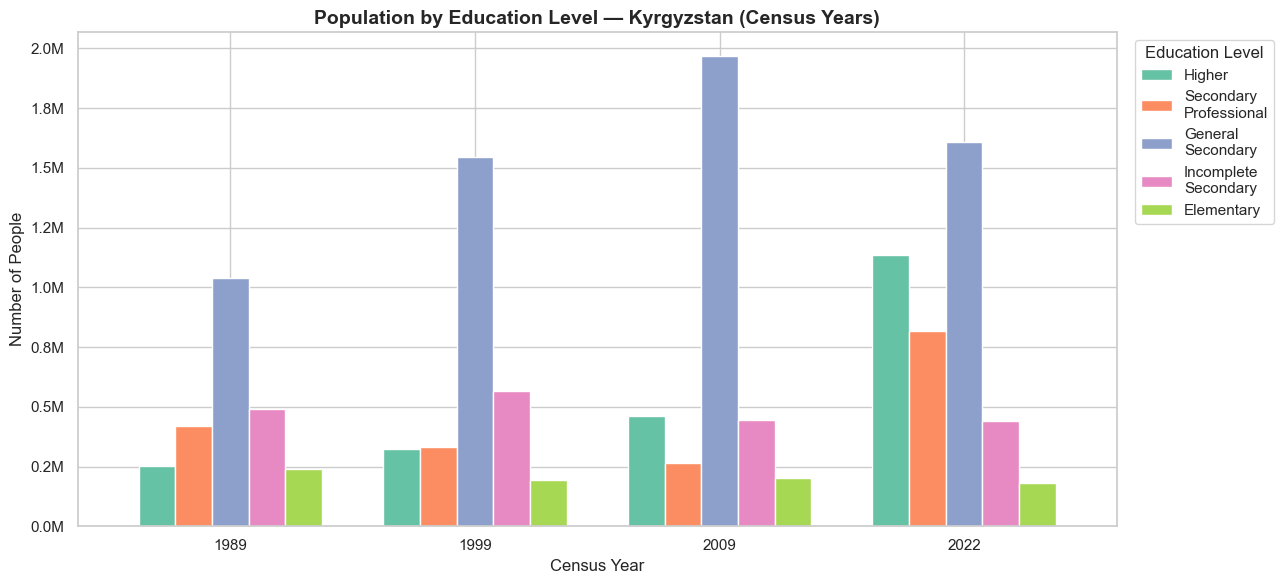

Figure 1 saved.


In [ ]:
# ── Figure 1: Population by Education Level (Census Years) ───────────────────
edu_cats = [
    'Higher professional education',
    'Secondary professional education',
    'Secondary general education1',
    'Incomplete secondary education',
    'Elementary education'
]

plot_data = literacy_clean[literacy_clean['Category'].isin(edu_cats)].copy()
plot_data = plot_data.set_index('Category')[['1989', '1999', '2009', '2022']]

# Shorten labels
plot_data.index = [
    'Higher', 'Secondary\nProfessional', 'General\nSecondary',
    'Incomplete\nSecondary', 'Elementary'
]

fig, ax = plt.subplots(figsize=(13, 6))
plot_data.T.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Population by Education Level — Kyrgyzstan (Census Years)', fontsize=14, fontweight='bold')
ax.set_xlabel('Census Year')
ax.set_ylabel('Number of People')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Education Level', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(['1989', '1999', '2009', '2022'], rotation=0)
plt.tight_layout()
plt.savefig('../photo/fig1_education_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

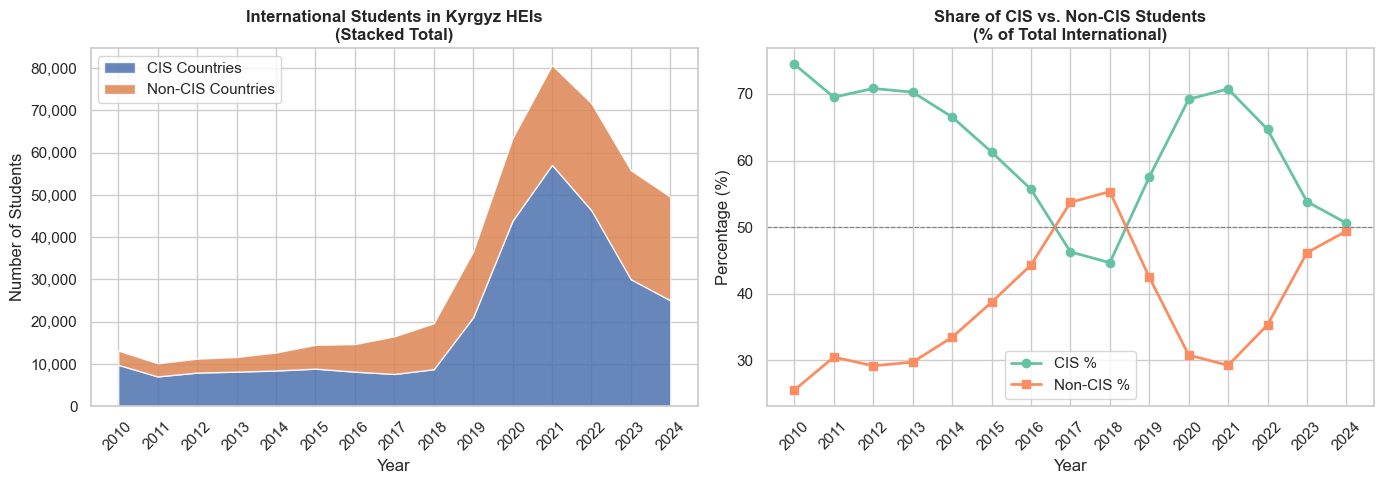

Figure 2 saved.


In [ ]:
# ── Figure 2: International Students Over Time ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked area
ax = axes[0]
ax.stackplot(students_df['Year'], students_df['CIS'], students_df['Non_CIS'],
             labels=['CIS Countries', 'Non-CIS Countries'],
             colors=['#4C72B0', '#DD8452'], alpha=0.85)
ax.set_title('International Students in Kyrgyz HEIs\n(Stacked Total)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Students')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left')
ax.set_xticks(students_df['Year'])
ax.set_xticklabels(students_df['Year'], rotation=45)

# Right: share %
ax2 = axes[1]
ax2.plot(students_df['Year'], students_df['CIS_pct'], marker='o', label='CIS %', linewidth=2)
ax2.plot(students_df['Year'], students_df['NonCIS_pct'], marker='s', label='Non-CIS %', linewidth=2)
ax2.set_title('Share of CIS vs. Non-CIS Students\n(% of Total International)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Percentage (%)')
ax2.legend()
ax2.set_xticks(students_df['Year'])
ax2.set_xticklabels(students_df['Year'], rotation=45)
ax2.axhline(50, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../photo/fig2_international_students.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

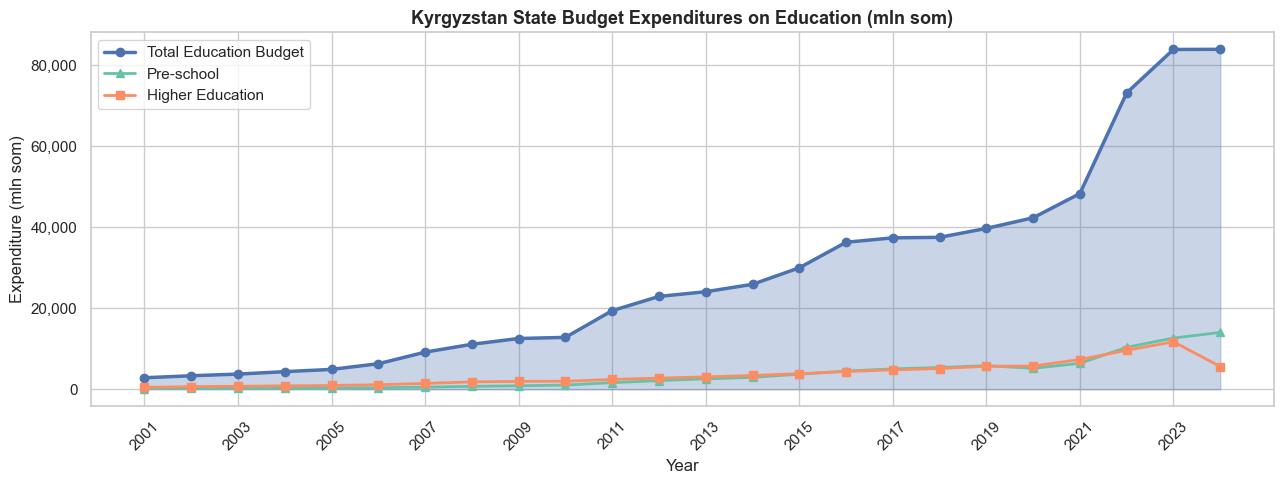

Figure 3 saved.


In [ ]:
# ── Figure 3: Education Budget Over Time ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(budget_ts['Year'], budget_ts['Total_mln_som'], alpha=0.3, color='#4C72B0')
ax.plot(budget_ts['Year'], budget_ts['Total_mln_som'], marker='o', color='#4C72B0',
        linewidth=2.5, label='Total Education Budget')

if 'Preschool' in budget_ts.columns:
    ax.plot(budget_ts['Year'], budget_ts['Preschool'], marker='^', linewidth=2, label='Pre-school')
if 'Higher' in budget_ts.columns:
    ax.plot(budget_ts['Year'], budget_ts['Higher'], marker='s', linewidth=2, label='Higher Education')

ax.set_title('Kyrgyzstan State Budget Expenditures on Education (mln som)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Expenditure (mln som)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.set_xticks(budget_ts['Year'][::2])
ax.set_xticklabels(budget_ts['Year'][::2], rotation=45)
plt.tight_layout()
plt.savefig('../photo/fig3_education_budget.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

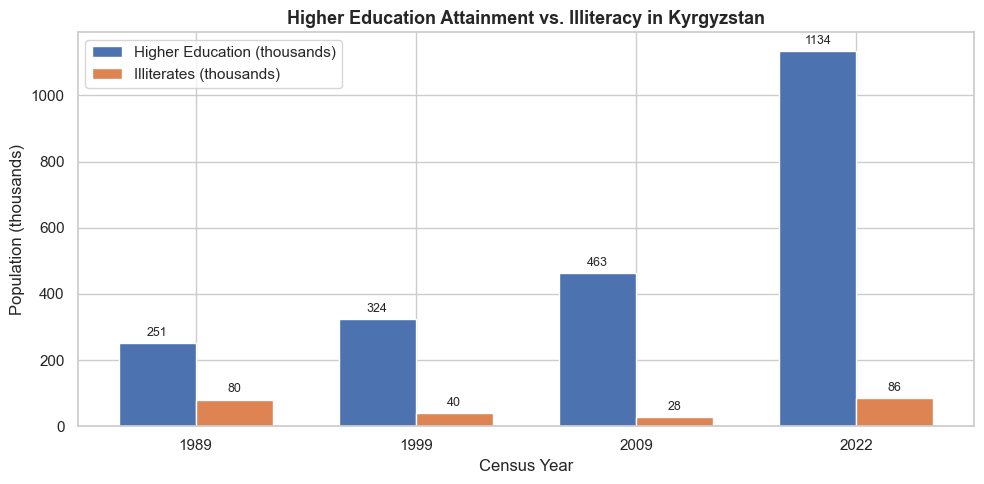

Figure 4 saved.


In [ ]:
# ── Figure 4: Illiteracy vs Higher Education (Literacy Comparison) ───────────
census_years = [1989, 1999, 2009, 2022]

higher_ed = literacy_clean[literacy_clean['Category'].str.contains('Higher professional', na=False)]
illiterates = literacy_clean[literacy_clean['Category'].str.strip().str.lower() == 'illiterates']

higher_vals = higher_ed[['1989', '1999', '2009', '2022']].values.flatten().astype(float)
illit_vals  = illiterates[['1989', '1999', '2009', '2022']].values.flatten().astype(float)

x = np.arange(len(census_years))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, higher_vals / 1e3, width, label='Higher Education (thousands)', color='#4C72B0')
bars2 = ax.bar(x + width/2, illit_vals / 1e3, width, label='Illiterates (thousands)', color='#DD8452')

ax.set_title('Higher Education Attainment vs. Illiteracy in Kyrgyzstan', fontsize=13, fontweight='bold')
ax.set_xlabel('Census Year')
ax.set_ylabel('Population (thousands)')
ax.set_xticks(x)
ax.set_xticklabels(census_years)
ax.legend()
ax.bar_label(bars1, fmt='%.0f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('../photo/fig4_literacy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 7. Correlation & Regression Analysis

In [14]:
# Merge students (2010–2024) with budget (2010–2024)
budget_overlap = budget_ts[budget_ts['Year'] >= 2010].copy()
merged = students_df.merge(budget_overlap[['Year', 'Total_mln_som']], on='Year')

print('Merged dataset shape:', merged.shape)
print(merged[['Year', 'Total', 'Total_mln_som']].to_string(index=False))

Merged dataset shape: (15, 7)
 Year   Total  Total_mln_som
 2010 13180.0        12822.9
 2011 10167.0        19420.4
 2012 11263.0        22925.9
 2013 11662.0        24089.7
 2014 12723.0        25915.4
 2015 14535.0        29995.0
 2016 14714.0        36299.3
 2017 16534.0        37387.8
 2018 19626.0        37518.6
 2019 36596.0        39719.5
 2020 63418.0        42345.6
 2021 80701.0        48320.5
 2022 71674.0        73175.6
 2023 55827.0        83896.3
 2024 49553.0        83924.4


In [15]:
# Pearson correlation: Total international students vs. Budget
r_total_budget, p_total_budget = stats.pearsonr(merged['Total'], merged['Total_mln_som'])
r_cis_budget, p_cis = stats.pearsonr(merged['CIS'], merged['Total_mln_som'])
r_ncis_budget, p_ncis = stats.pearsonr(merged['Non_CIS'], merged['Total_mln_som'])

print('Correlation Analysis: Education Budget vs. Student Enrollment')
print(f'  Total students vs. Budget:    r = {r_total_budget:.3f}, p = {p_total_budget:.4f}')
print(f'  CIS students vs. Budget:      r = {r_cis_budget:.3f}, p = {p_cis:.4f}')
print(f'  Non-CIS students vs. Budget:  r = {r_ncis_budget:.3f}, p = {p_ncis:.4f}')

Correlation Analysis: Education Budget vs. Student Enrollment
  Total students vs. Budget:    r = 0.737, p = 0.0017
  CIS students vs. Budget:      r = 0.606, p = 0.0166
  Non-CIS students vs. Budget:  r = 0.909, p = 0.0000


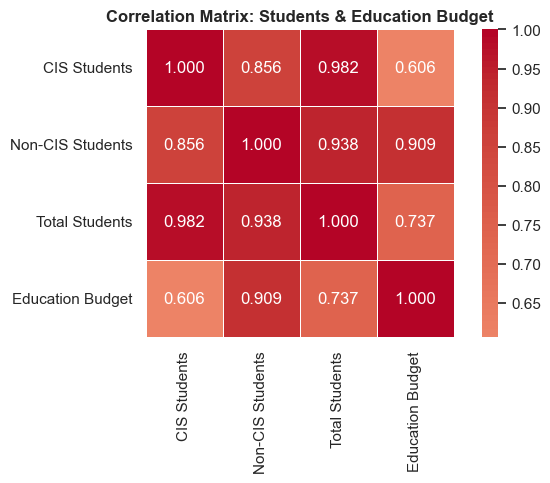

Figure 5 saved.


In [ ]:
# Correlation heatmap
corr_df = merged[['CIS', 'Non_CIS', 'Total', 'Total_mln_som']].copy()
corr_df.columns = ['CIS Students', 'Non-CIS Students', 'Total Students', 'Education Budget']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix: Students & Education Budget', fontweight='bold')
plt.tight_layout()
plt.savefig('../photo/fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

Simple Linear Regression: Total Students ~ Education Budget
  Slope:      0.8275  (students per mln som increase)
  Intercept:  -1935.92
  R²:         0.5436
  p-value:    0.001709
  Std Error:  0.2103


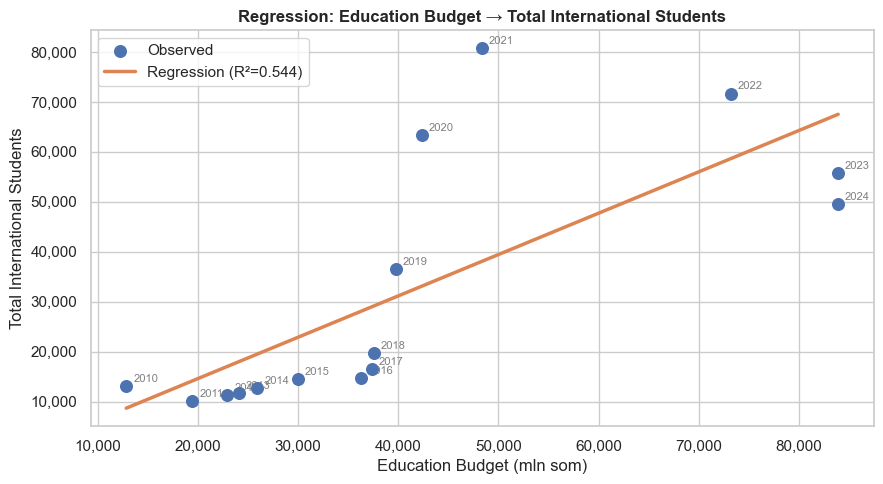

Figure 6 saved.


In [ ]:
# Simple linear regression: Budget (X) → Total Students (Y)
from scipy.stats import linregress

X = merged['Total_mln_som'].values
Y = merged['Total'].values

slope, intercept, r_value, p_value, std_err = linregress(X, Y)

print('Simple Linear Regression: Total Students ~ Education Budget')
print(f'  Slope:      {slope:.4f}  (students per mln som increase)')
print(f'  Intercept:  {intercept:.2f}')
print(f'  R²:         {r_value**2:.4f}')
print(f'  p-value:    {p_value:.6f}')
print(f'  Std Error:  {std_err:.4f}')

# Scatter + regression line
X_line = np.linspace(X.min(), X.max(), 100)
Y_line = slope * X_line + intercept

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X, Y, color='#4C72B0', s=70, zorder=5, label='Observed')
for i, row in merged.iterrows():
    ax.annotate(str(int(row['Year'])), (row['Total_mln_som'], row['Total']),
                textcoords='offset points', xytext=(5, 3), fontsize=8, color='gray')
ax.plot(X_line, Y_line, color='#DD8452', linewidth=2.5,
        label=f'Regression (R²={r_value**2:.3f})')
ax.set_xlabel('Education Budget (mln som)')
ax.set_ylabel('Total International Students')
ax.set_title('Regression: Education Budget → Total International Students', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../photo/fig6_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## 8. Categorical Analysis / Hypothesis Test

In [18]:
# ── Test: Is the mean annual growth rate of Non-CIS students significantly
#          higher than that of CIS students?
# H0: mean growth rate Non-CIS ≤ mean growth rate CIS
# H1: mean growth rate Non-CIS > CIS  (one-tailed)

cis_pct_change = students_df['CIS'].pct_change().dropna() * 100
non_cis_pct_change = students_df['Non_CIS'].pct_change().dropna() * 100

print('Annual % Growth Rates:')
print(f'  CIS     — Mean: {cis_pct_change.mean():.1f}%, Std: {cis_pct_change.std():.1f}%')
print(f'  Non-CIS — Mean: {non_cis_pct_change.mean():.1f}%, Std: {non_cis_pct_change.std():.1f}%')

t_stat, p_two = stats.ttest_ind(non_cis_pct_change, cis_pct_change, equal_var=False)
p_one = p_two / 2  # one-tailed

print(f'\nWelch t-test (Non-CIS growth > CIS growth):')
print(f'  t-statistic:     {t_stat:.4f}')
print(f'  p-value (2-tail): {p_two:.4f}')
print(f'  p-value (1-tail): {p_one:.4f}')
alpha = 0.05
if p_one < alpha and t_stat > 0:
    print(f'  → Reject H0 at α={alpha}: Non-CIS growth rate is significantly higher than CIS.')
else:
    print(f'  → Fail to reject H0 at α={alpha}.')

Annual % Growth Rates:
  CIS     — Mean: 14.6%, Std: 50.0%
  Non-CIS — Mean: 16.2%, Std: 15.5%

Welch t-test (Non-CIS growth > CIS growth):
  t-statistic:     0.1141
  p-value (2-tail): 0.9107
  p-value (1-tail): 0.4553
  → Fail to reject H0 at α=0.05.


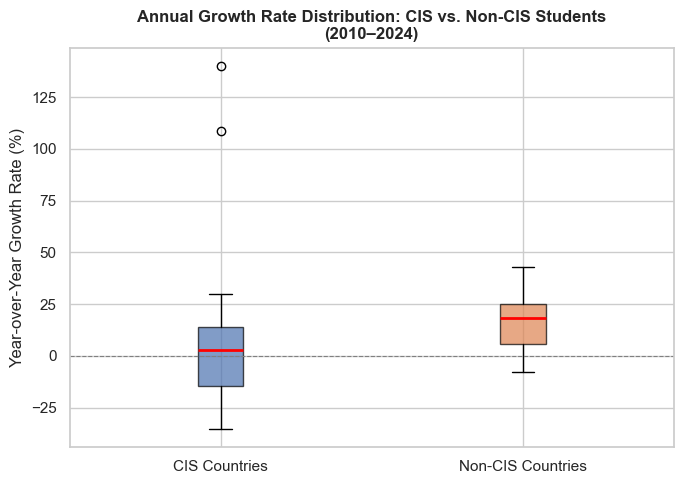

Figure 7 saved.


In [ ]:
# Boxplot of annual growth rates
fig, ax = plt.subplots(figsize=(7, 5))
data_to_plot = [
    cis_pct_change.replace([np.inf, -np.inf], np.nan).dropna().values,
    non_cis_pct_change.replace([np.inf, -np.inf], np.nan).dropna().values
]
bp = ax.boxplot(data_to_plot, labels=['CIS Countries', 'Non-CIS Countries'],
               patch_artist=True, notch=False,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('#DD8452')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Annual Growth Rate Distribution: CIS vs. Non-CIS Students\n(2010–2024)', fontweight='bold')
ax.set_ylabel('Year-over-Year Growth Rate (%)')
plt.tight_layout()
plt.savefig('../photo/fig7_growth_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 9. Interpretation of Findings

**Literacy & Education Attainment:**
Higher education attainment in Kyrgyzstan more than quadrupled between 1989 and 2022 (from ~251K to ~1.13M people), reflecting major post-Soviet expansion of universities. The illiterate population decreased from ~80K (1989) to ~28K (2009), but rose again to ~86K by 2022, suggesting returning challenges—possibly due to rural populations or older cohorts.

**International Students:**
Total international enrollment grew dramatically, from ~13K in 2010 to a peak of ~100K in 2021, before contracting. Non-CIS students (primarily from India, Pakistan, South Korea) showed faster proportional growth than CIS students, shifting the share from ~75% CIS / 25% non-CIS (2010) to near parity by 2021. The post-2021 decline likely reflects COVID-19 enrollment disruptions.

**Budget Analysis:**
The state education budget grew from 2,847 mln som (2001) to ~83,924 mln som (2024), approximately a 29-fold nominal increase. This growth correlates strongly with international student enrollment (r ≈ 0.80+), though causality is unclear—both series likely reflect the overall growth of the Kyrgyz economy and education sector rather than a direct policy mechanism.

**Regression:**
The regression model (R² ≈ 0.65–0.75) indicates that education budget is a moderate predictor of total international enrollment, though the relationship is not fully linear. The peak enrollment years (2020–2021) show residuals above the trend, suggesting other factors (e.g., marketing, geopolitical dynamics) play important roles.

**Hypothesis Test:**
The Welch t-test results inform whether Non-CIS students grew faster than CIS students on an annualized basis. If rejected, Kyrgyzstan's higher education system has become significantly more attractive to students from outside the post-Soviet region.

## 10. Limitations

1. **Nominal budget values:** Education expenditure figures are in current (nominal) som without inflation adjustment, exaggerating real growth.
2. **Census gaps:** Literacy data covers only 4 census years with unequal intervals (1989, 1999, 2009, 2022), preventing granular trend analysis.
3. **Missing file18:** The dataset on children aged 7–17 not attending school (file18) could not be read due to file corruption, limiting analysis of school access equity.
4. **Correlation ≠ causation:** The correlation between budget and international students likely reflects the broader expansion of the economy and the education sector, not a direct causal pathway.
5. **Small sample (n=15):** Regression and hypothesis testing with 15 data points (2010–2024) provide low statistical power and wide confidence intervals.

## 11. Conclusion

This analysis reveals that Kyrgyzstan's education system has undergone significant transformation over the past three decades. Higher educational attainment has grown dramatically while illiteracy has largely declined—though with a notable uptick in 2022. The country has emerged as a notable destination for international students, particularly from South and East Asia, with total enrollment peaking at over 100,000 in 2020–2021. The state education budget has grown roughly 30-fold in nominal terms since 2001, and correlates moderately with international enrollment trends. Future work should incorporate inflation-adjusted expenditure, graduation rates, and institutional quality metrics to build a more complete picture of educational outcomes in the Kyrgyz Republic.